In [53]:
from datasets import load_dataset
import pandas as pd
import os
import re

# Κατηγορίες με τα review + meta configs
categories_configs = {
    "Subscription_Boxes": {
        "review": "raw_review_Subscription_Boxes",
        "meta": "raw_meta_Subscription_Boxes"
    },
    "Magazine_Subscriptions": {
        "review": "raw_review_Magazine_Subscriptions",
        "meta": "raw_meta_Magazine_Subscriptions"
    },
    "Gift_Cards": {
        "review": "raw_review_Gift_Cards",
        "meta": "raw_meta_Gift_Cards"
    },
    "Digital_Music": {
        "review": "raw_review_Digital_Music",
        "meta": "raw_meta_Digital_Music"
    },
    "Handmade_Products": {
        "review": "raw_review_Handmade_Products",
        "meta": "raw_meta_Handmade_Products"
    }
}

chunk_size = 10000

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for category, configs in categories_configs.items():
    print(f"\n Φόρτωση και επεξεργασία για: {category}")
    filename = f"{category}.csv"

    if os.path.exists(filename):
        os.remove(filename)

    try:
        meta_dataset = load_dataset(
            "McAuley-Lab/Amazon-Reviews-2023",
            configs["meta"],
            split="full",
            trust_remote_code=True
        )
        df_meta = pd.json_normalize(meta_dataset)

        if 'parent_asin' not in df_meta.columns:
            raise ValueError(" Δεν βρέθηκε το πεδίο 'parent_asin' στο metadata.")

        df_meta = df_meta.rename(columns={
            "parent_asin": "asin",
            "title": "product_title"
        })

        meta_columns = ['asin', 'product_title', 'price', 'average_rating', 'rating_number', 'features']
        df_meta = df_meta[[col for col in meta_columns if col in df_meta.columns]]

        if 'features' in df_meta.columns:
            df_meta['features'] = df_meta['features'].apply(
                lambda x: eval(x) if isinstance(x, str) and x.startswith('[') else x
            )

        for col in ['price', 'average_rating', 'rating_number']:
            if col in df_meta.columns:
                df_meta[col] = pd.to_numeric(df_meta[col], errors='coerce')

        print(f"Metadata OK για {category} | Σήλες: {df_meta.columns.tolist()}")

    except Exception as e:
        print(f"Σφάλμα στη φόρτωση metadata: {e}")
        continue

    try:
        review_dataset = load_dataset(
            "McAuley-Lab/Amazon-Reviews-2023",
            configs["review"],
            split="full",
            streaming=True
        )
    except Exception as e:
        print(f"Σφάλμα στη φόρτωση reviews: {e}")
        continue

    buffer = []
    total = 0

    for i, example in enumerate(review_dataset):
        buffer.append(example)

        if len(buffer) >= chunk_size:
            df = pd.DataFrame(buffer)
            useful_columns = ['rating', 'text', 'asin', 'user_id', 'timestamp', 'verified_purchase']
            df = df[[col for col in useful_columns if col in df.columns]]
            df = df.dropna(subset=['rating', 'text'])
            df['text'] = df['text'].apply(clean_text)
            df = pd.merge(df, df_meta, how='left', on='asin')

            # Συμπλήρωση κενών product_title με χάρτη asin
            if 'product_title' in df.columns:
                missing = df['product_title'].isna()
                if missing.any():
                    title_map = df_meta.set_index('asin')['product_title'].to_dict()
                    df.loc[missing, 'product_title'] = df.loc[missing, 'asin'].map(title_map)

            df.to_csv(filename, mode='a', header=(i < chunk_size), index=False)
            total += len(df)
            # print(f"Αποθηκεύτηκαν {total} γραμμές...")
            buffer = []

    if buffer:
        df = pd.DataFrame(buffer)
        df = df[[col for col in useful_columns if col in df.columns]]
        df = df.dropna(subset=['rating', 'text'])
        df['text'] = df['text'].apply(clean_text)
        df = pd.merge(df, df_meta, how='left', on='asin')

        if 'product_title' in df.columns:
            missing = df['product_title'].isna()
            if missing.any():
                title_map = df_meta.set_index('asin')['product_title'].to_dict()
                df.loc[missing, 'product_title'] = df.loc[missing, 'asin'].map(title_map)

        df.to_csv(filename, mode='a', header=(total == 0), index=False)
        total += len(df)
        print(f" Τελικό chunk αποθηκεύτηκε. Σύνολο: {total} γραμμές.")

print("\n Ολοκληρώθηκε η λήψη, συγχώνευση και καθαρισμός όλων των κατηγοριών.")



 Φόρτωση και επεξεργασία για: Subscription_Boxes
Metadata OK για Subscription_Boxes | Σήλες: ['asin', 'product_title', 'price', 'average_rating', 'rating_number', 'features']
 Τελικό chunk αποθηκεύτηκε. Σύνολο: 16216 γραμμές.

 Φόρτωση και επεξεργασία για: Magazine_Subscriptions
Metadata OK για Magazine_Subscriptions | Σήλες: ['asin', 'product_title', 'price', 'average_rating', 'rating_number', 'features']
 Τελικό chunk αποθηκεύτηκε. Σύνολο: 71497 γραμμές.

 Φόρτωση και επεξεργασία για: Gift_Cards
Metadata OK για Gift_Cards | Σήλες: ['asin', 'product_title', 'price', 'average_rating', 'rating_number', 'features']
 Τελικό chunk αποθηκεύτηκε. Σύνολο: 152410 γραμμές.

 Φόρτωση και επεξεργασία για: Digital_Music
Metadata OK για Digital_Music | Σήλες: ['asin', 'product_title', 'price', 'average_rating', 'rating_number', 'features']
 Τελικό chunk αποθηκεύτηκε. Σύνολο: 130434 γραμμές.

 Φόρτωση και επεξεργασία για: Handmade_Products
Metadata OK για Handmade_Products | Σήλες: ['asin', 'produc

<ipython-input-39-d6f1550a1ceb>:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Κατηγορία', loc='upper left', bbox_to_anchor=(1, 1))
<ipython-input-39-d6f1550a1ceb>:29: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


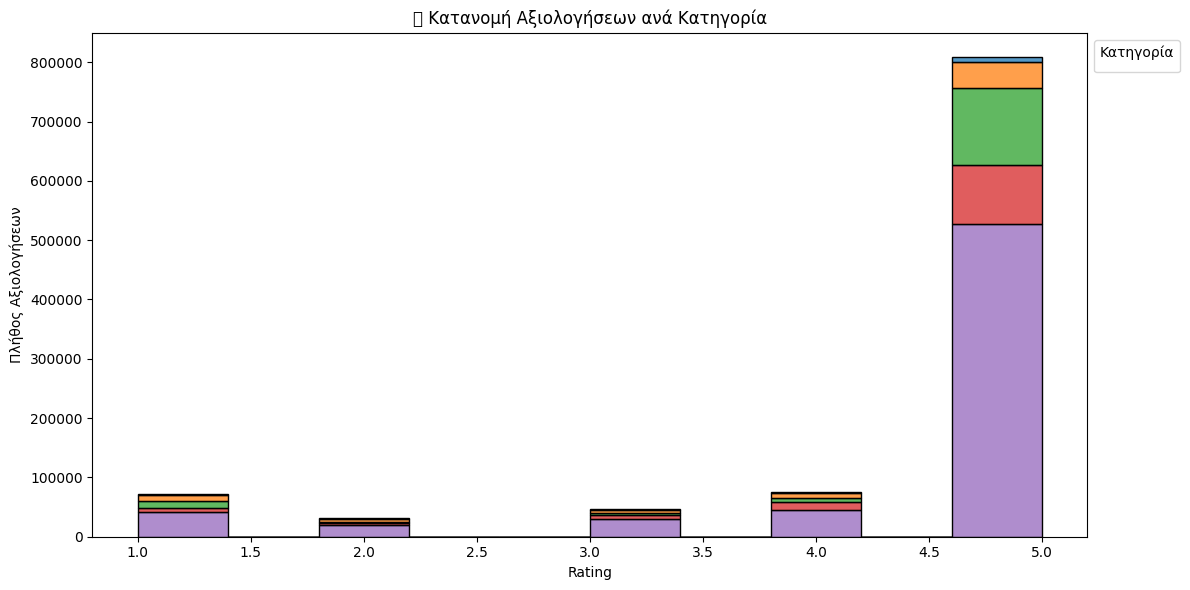

<ipython-input-39-d6f1550a1ceb>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=mean_df, x="category", y="rating", palette="viridis")
<ipython-input-39-d6f1550a1ceb>:43: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


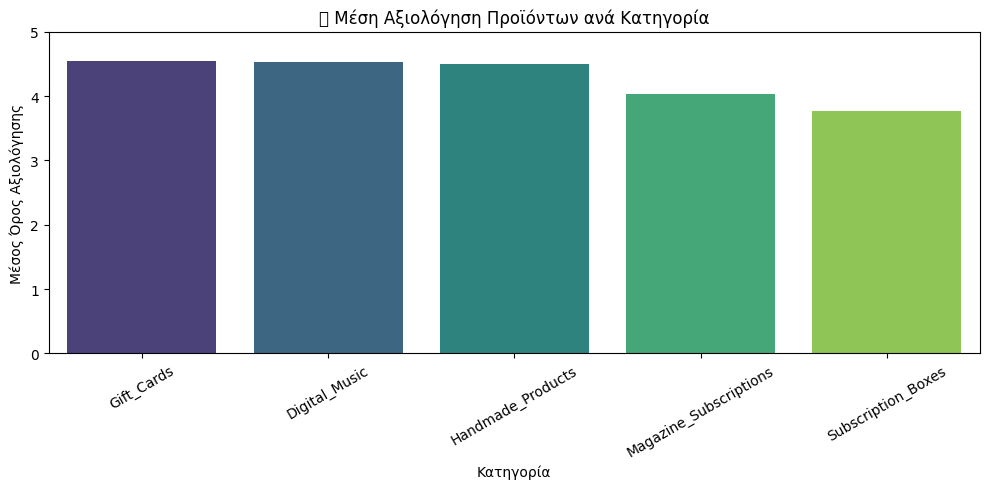

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#  Διαβάζουμε και συνενώνουμε όλα τα CSV
categories = {
    "Subscription_Boxes": "Subscription_Boxes.csv",
    "Magazine_Subscriptions": "Magazine_Subscriptions.csv",
    "Gift_Cards": "Gift_Cards.csv",
    "Digital_Music": "Digital_Music.csv",
    "Handmade_Products": "Handmade_Products.csv"
}

dfs = []
for cat, file in categories.items():
    df = pd.read_csv(file)
    df["category"] = cat
    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

#  Ιστογράφημα αξιολογήσεων ανά κατηγορία
plt.figure(figsize=(12, 6))
sns.histplot(data=df_all, x='rating', hue='category', multiple='stack', bins=10)
plt.title(' Κατανομή Αξιολογήσεων ανά Κατηγορία')
plt.xlabel('Rating')
plt.ylabel('Πλήθος Αξιολογήσεων')
plt.legend(title='Κατηγορία', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

#  Barplot με μέσες αξιολογήσεις ανά κατηγορία
mean_ratings = df_all.groupby("category")["rating"].mean().sort_values(ascending=False)
mean_df = mean_ratings.reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=mean_df, x="category", y="rating", palette="viridis")
plt.title("Μέση Αξιολόγηση Προϊόντων ανά Κατηγορία")
plt.xlabel("Κατηγορία")
plt.ylabel("Μέσος Όρος Αξιολόγησης")
plt.xticks(rotation=30)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()


In [54]:
# ## Ερώτημα 2 – Πολλά Reviews, Χαμηλό Rating
# Εντοπίζουμε προϊόντα με υψηλό αριθμό αξιολογήσεων αλλά χαμηλή μέση βαθμολογία (π.χ. κάτω από 3).
# Έπειτα εξετάζουμε τις συχνότερες λέξεις στις κριτικές τους μέσω Word Cloud.

import pandas as pd
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

#  Φιλτράρουμε τα προϊόντα με πολλά reviews και χαμηλή μέση βαθμολογία
low_rated = df_all[(df_all['rating_number'] >= 50) & (df_all['average_rating'] < 3.5)]


print(f"Βρέθηκαν {low_rated['asin'].nunique()} προϊόντα με πολλά reviews και χαμηλή μέση βαθμολογία.")

#  Παίρνουμε όλες τις κριτικές (text) για αυτά τα προϊόντα
low_asins = low_rated['asin'].unique()
low_reviews = df_all[df_all['asin'].isin(low_asins) & df_all['text'].notna()]

#  Ενώνουμε όλα τα κείμενα σε 1 string
text_blob = " ".join(low_reviews["text"].astype(str).tolist())

# Ορισμός stopwords για καθαρότερη λέξη-σύννεφο
stopwords = set(STOPWORDS)
stopwords.update(["product", "amazon", "box", "one", "get", "would", "like", "just"])

print("Αριθμός κριτικών:", len(low_reviews))
print("Πρώτο κείμενο:", low_reviews['text'].iloc[0] if len(low_reviews) > 0 else "Κανένα")

keywords = [
    "magazine", "issue", "disappointed", "dont", "cheap", "broken", "time", "got", "really",
    "money", "price", "read", "review", "products", "never", "still", "return", "look", "try",
    "product", "expected", "useless", "bad", "wait", "shipping", "small", "low", "didnt", "stop", "charged"
]

print("Συχνότερες λέξεις-κλειδιά σε κριτικές χαμηλής βαθμολογίας:\n")
for word in keywords:
    print(f"– {word}")




Βρέθηκαν 100 προϊόντα με πολλά reviews και χαμηλή μέση βαθμολογία.
Αριθμός κριτικών: 1688
Πρώτο κείμενο: with a couple of the items i wasnt quite sure of their intended applications cheap packaging cheap quality no ingredients list etc tried to contact seller no luck
Συχνότερες λέξεις-κλειδιά σε κριτικές χαμηλής βαθμολογίας:

– magazine
– issue
– disappointed
– dont
– cheap
– broken
– time
– got
– really
– money
– price
– read
– review
– products
– never
– still
– return
– look
– try
– product
– expected
– useless
– bad
– wait
– shipping
– small
– low
– didnt
– stop
– charged


In [55]:
# ## Ερώτημα 3 – Top 5 Best-Selling Προϊόντα ανά Κατηγορία
# Εντοπισμός των πιο πολυπουλημένων προϊόντων βάσει review count (rating_number)

import pandas as pd

categories = [
    "Subscription_Boxes",
    "Magazine_Subscriptions",
    "Gift_Cards",
    "Digital_Music",
    "Handmade_Products"
]

for cat in categories:
    print(f"\n Κατηγορία: {cat}")
    try:
        df = pd.read_csv(f"{cat}.csv")
    except FileNotFoundError:
        print(" Δεν βρέθηκε το αρχείο.")
        continue

    if 'asin' not in df.columns or 'product_title' not in df.columns:
        print(" Λείπουν βασικά πεδία.")
        continue

    # Ομαδοποίηση και μέτρηση reviews ανά προϊόν
    review_counts = df.groupby('asin').size().reset_index(name='review_count')

    # Προσθήκη τίτλου & χαρακτηριστικών
    product_info = df[['asin', 'product_title', 'features']].drop_duplicates(subset='asin')

    merged = pd.merge(review_counts, product_info, on='asin')
    top_5 = merged.sort_values(by='review_count', ascending=False).head(5)

    import ast

    print(" Top 5 προϊόντα:")
    for idx, row in top_5.iterrows():
        title = row['product_title'] if pd.notna(row['product_title']) else '[Χωρίς τίτλο]'
        print(f"\n Τίτλος: {title}")
        print(f"    Αριθμός αξιολογήσεων: {row['review_count']}")

        features = row.get('features', [])

        # Αν τα features είναι string τύπου "['x', 'y']", μετατροπή σε λίστα
        if isinstance(features, str):
            try:
                features = ast.literal_eval(features)
            except Exception:
                features = []

        if isinstance(features, list) and features:
            print("    Χαρακτηριστικά:")
            for feat in features:
                print(f"      - {feat}")
        else:
            print("    Χαρακτηριστικά: [Δεν υπάρχουν]")




 Κατηγορία: Subscription_Boxes
 Top 5 προϊόντα:

 Τίτλος: [Χωρίς τίτλο]
    Αριθμός αξιολογήσεων: 1772
    Χαρακτηριστικά: [Δεν υπάρχουν]

 Τίτλος: [Χωρίς τίτλο]
    Αριθμός αξιολογήσεων: 600
    Χαρακτηριστικά: [Δεν υπάρχουν]

 Τίτλος: [Χωρίς τίτλο]
    Αριθμός αξιολογήσεων: 572
    Χαρακτηριστικά: [Δεν υπάρχουν]

 Τίτλος: STEM Club Toy Subscription: 3-4 year olds
    Αριθμός αξιολογήσεων: 545
    Χαρακτηριστικά:
      - Subscribe and save up to 40% on STEM Toys
      - Discover highly-rated STEM (Science, Technology, Engineering, & Math) Toys from leading brands handpicked by Amazon’s Toy experts
      - Toys encourage understanding and exploration of STEM subjects for children in a fun and entertaining way
      - Support the development of essential skills like logic, creativity, and problem-solving
      - New for 2020 - STEM Club now includes limited selection of Arts and Crafts to encourage creativity, inspire imagination and innovation in children

 Τίτλος: STEM Club Toy Subsc

<ipython-input-51-88d1316ee7c1>:49: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


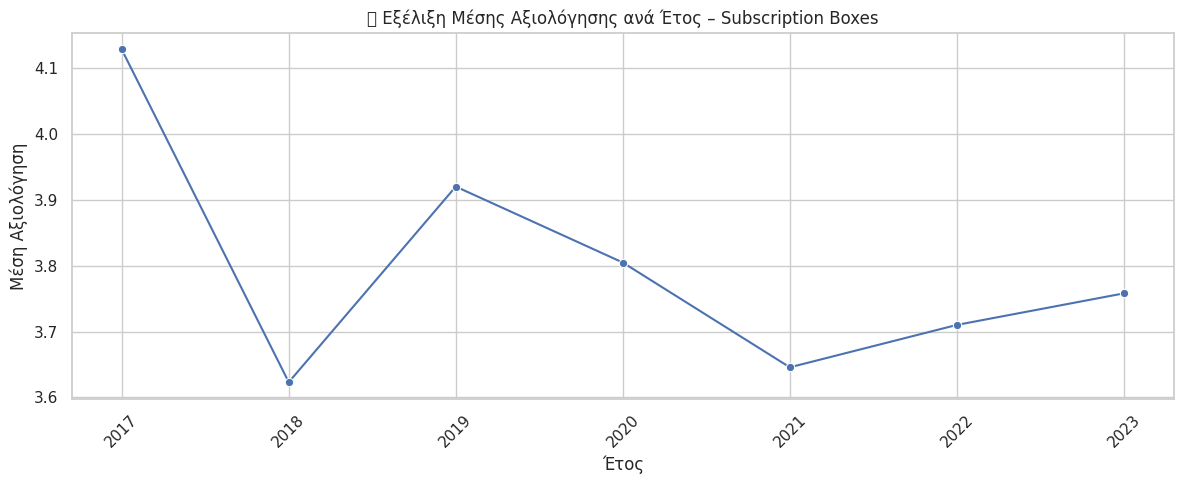

<ipython-input-51-88d1316ee7c1>:63: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


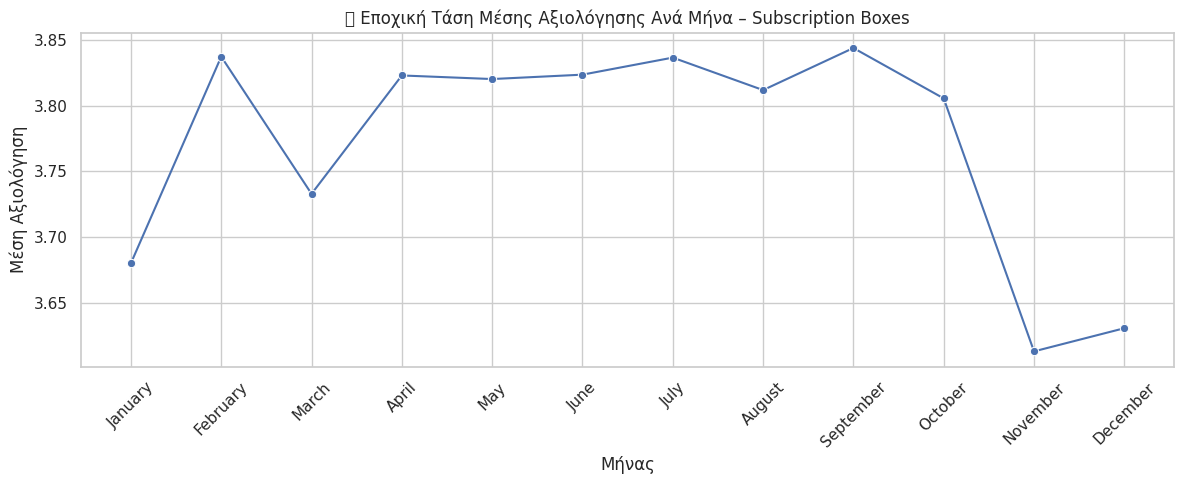

<ipython-input-51-88d1316ee7c1>:49: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


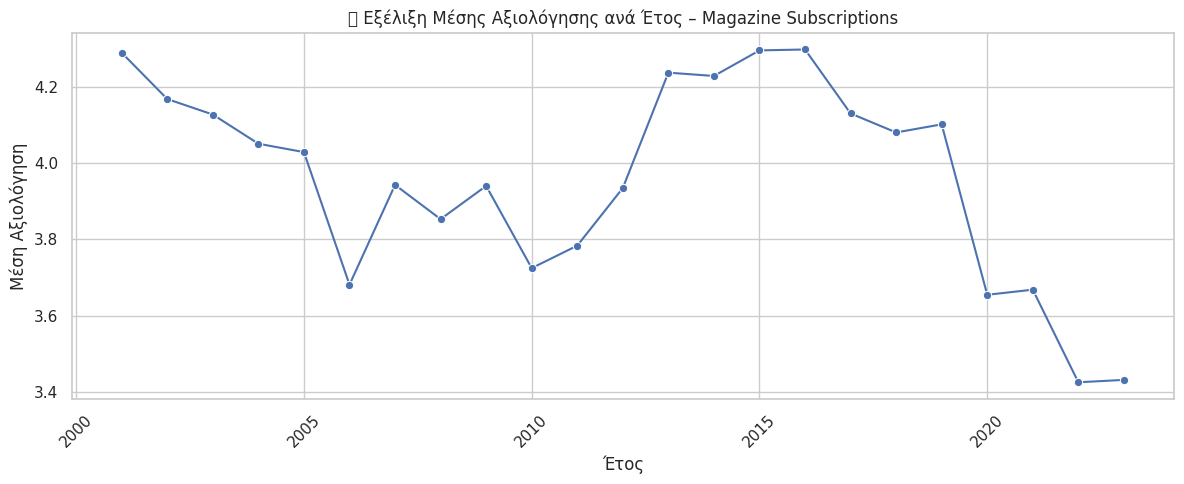

<ipython-input-51-88d1316ee7c1>:63: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


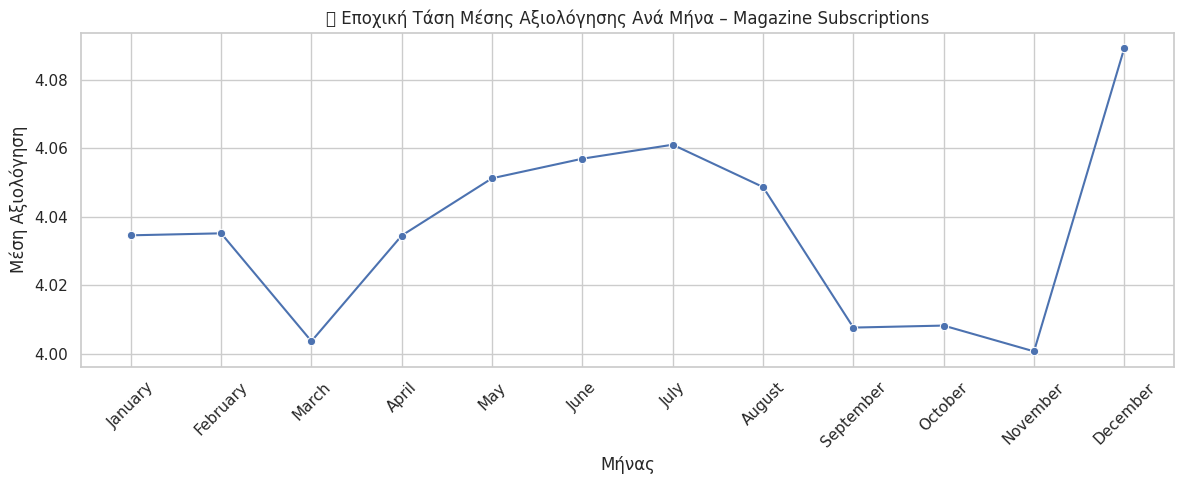

<ipython-input-51-88d1316ee7c1>:49: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


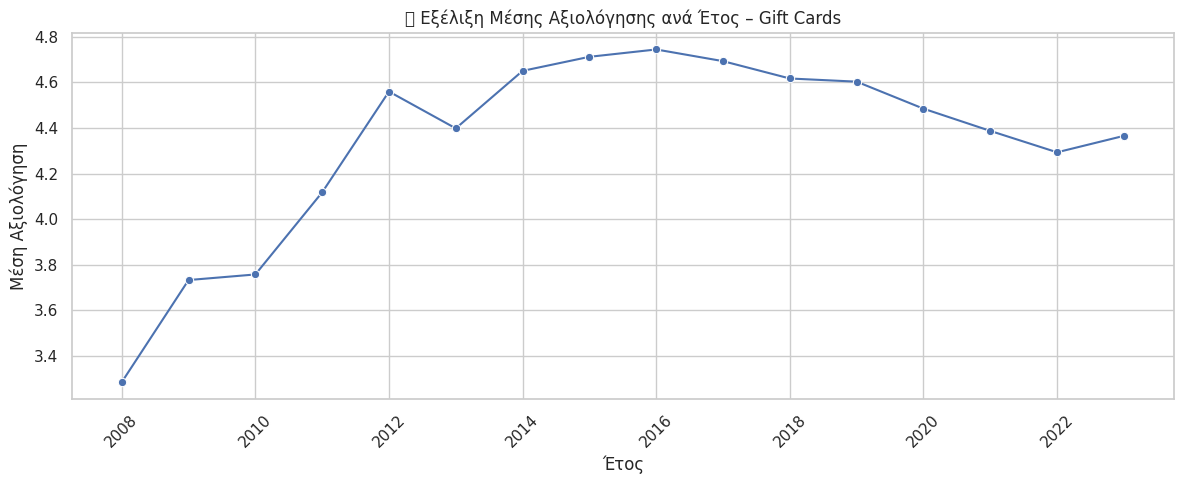

<ipython-input-51-88d1316ee7c1>:63: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


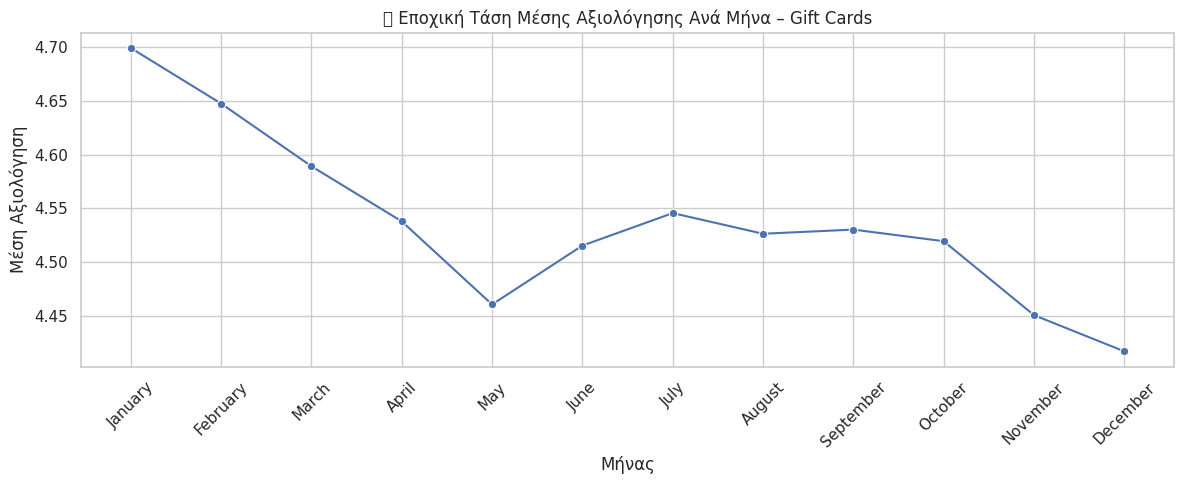

<ipython-input-51-88d1316ee7c1>:49: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


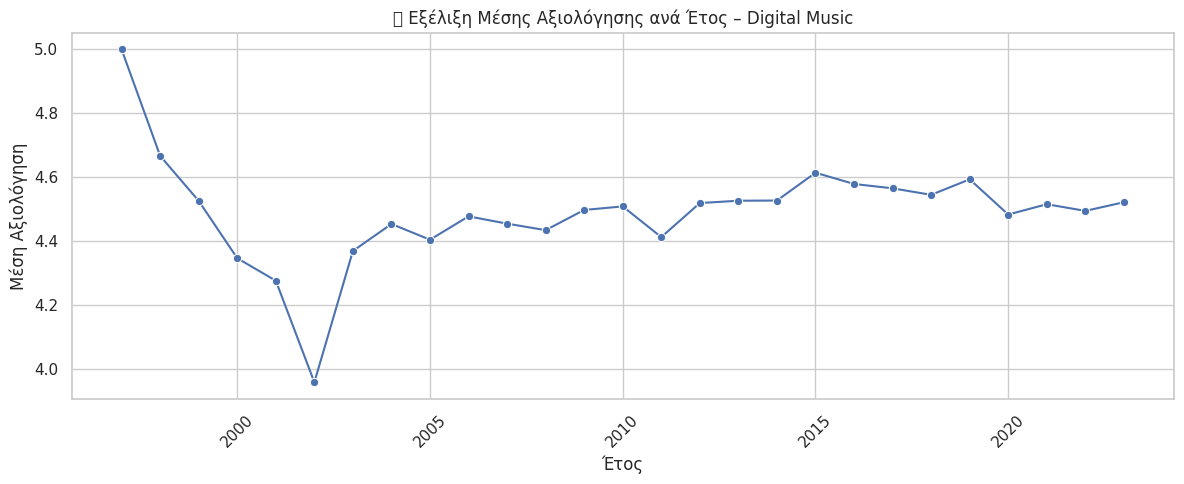

<ipython-input-51-88d1316ee7c1>:63: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


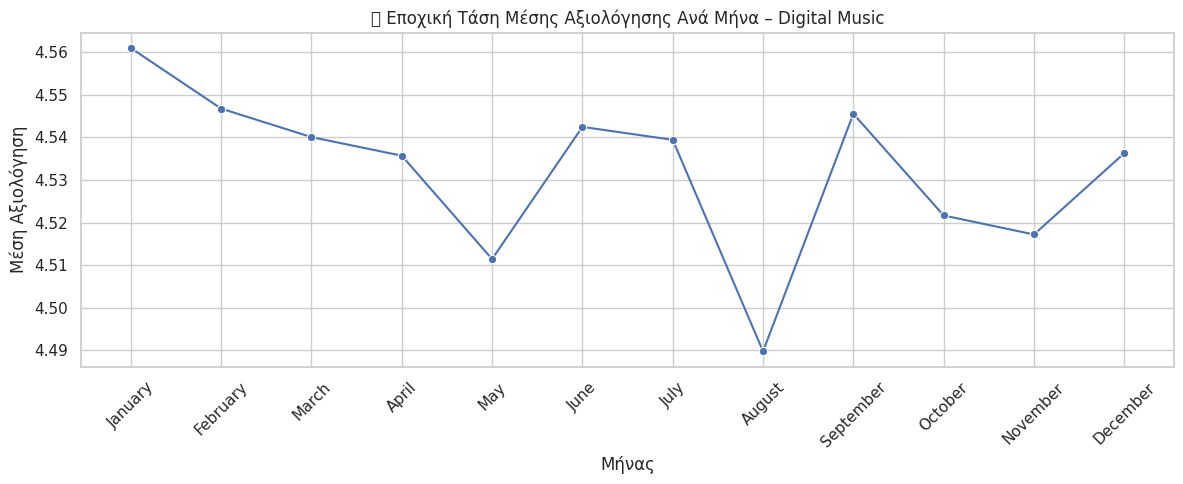

<ipython-input-51-88d1316ee7c1>:49: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


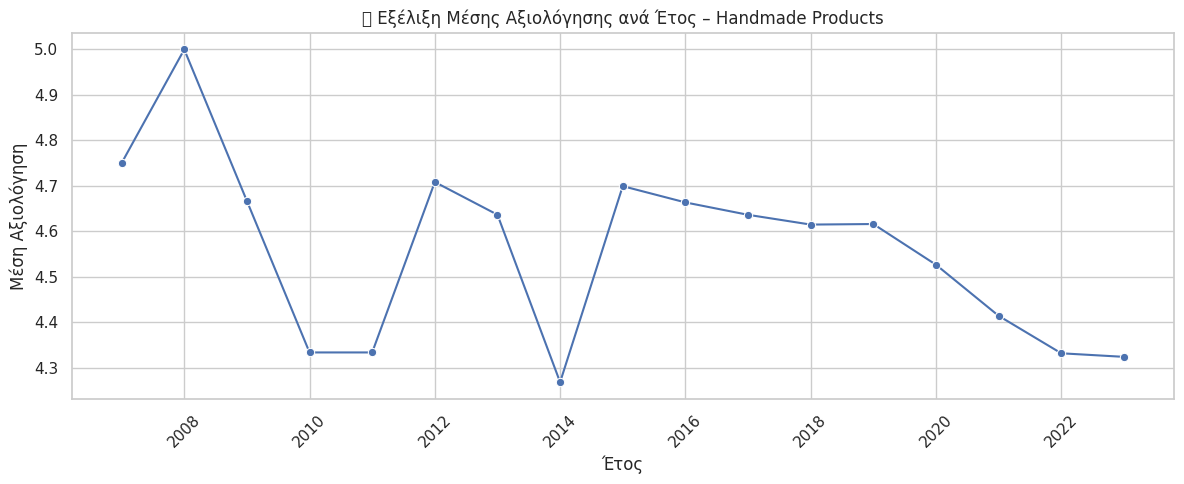

<ipython-input-51-88d1316ee7c1>:63: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


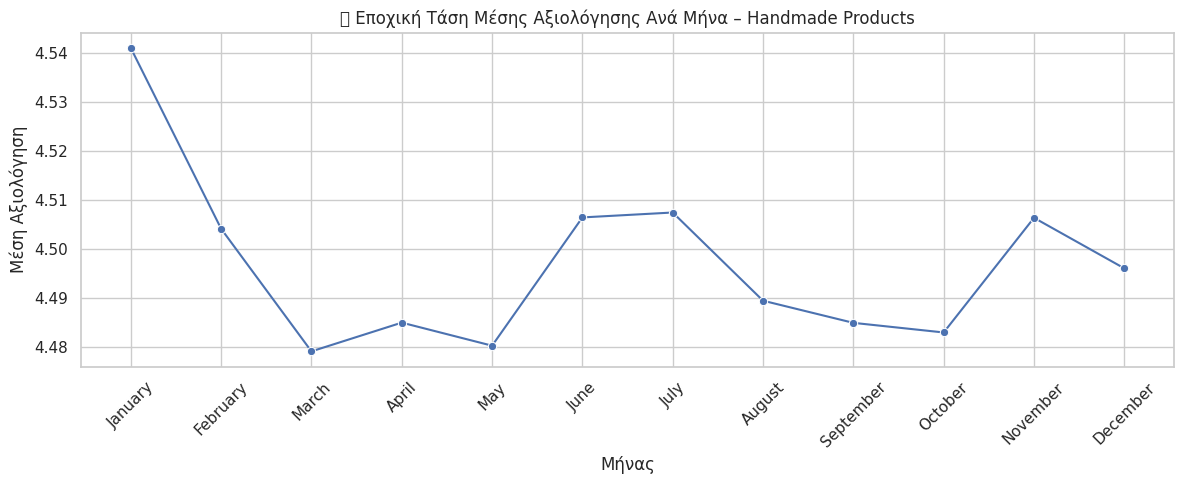

In [ ]:
# Ερώτημα 4

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime

# Ορισμός ονομάτων αρχείων
csv_files = [
    "Subscription_Boxes.csv",
    "Magazine_Subscriptions.csv",
    "Gift_Cards.csv",
    "Digital_Music.csv",
    "Handmade_Products.csv"
]

# Ρύθμιση στυλ γραφημάτων
sns.set(style="whitegrid")

# Δημιουργία γραφημάτων για κάθε κατηγορία
for file in csv_files:
    if not os.path.exists(file):
        continue

    category = file.replace(".csv", "").replace("_", " ")

    df = pd.read_csv(file)

    # Φιλτράρισμα απαραίτητων πεδίων
    if 'timestamp' not in df.columns or 'rating' not in df.columns:
        continue

    df = df[['timestamp', 'rating']].dropna()
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms', errors='coerce')
    df = df.dropna(subset=['timestamp'])

    df['year'] = df['timestamp'].dt.year
    df['month'] = df['timestamp'].dt.month_name()
    df['month_num'] = df['timestamp'].dt.month

    # ➤ Διάγραμμα: Εξέλιξη Μέσης Βαθμολογίας Ανά Έτος
    yearly_avg = df.groupby('year')['rating'].mean().reset_index()

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=yearly_avg, x='year', y='rating', marker='o')
    plt.title(f"📈 Εξέλιξη Μέσης Αξιολόγησης ανά Έτος – {category}")
    plt.ylabel("Μέση Αξιολόγηση")
    plt.xlabel("Έτος")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # ➤ Διάγραμμα: Εποχική Τάση Ανά Μήνα (Αθροιστικά)
    monthly_avg = df.groupby('month_num').agg({'rating': 'mean'}).reset_index()
    monthly_avg['month'] = monthly_avg['month_num'].apply(lambda x: datetime(2000, x, 1).strftime('%B'))
    monthly_avg = monthly_avg.sort_values('month_num')

    plt.figure(figsize=(12, 5))
    sns.lineplot(data=monthly_avg, x='month', y='rating', marker='o')
    plt.title(f" Εποχική Τάση Μέσης Αξιολόγησης Ανά Μήνα – {category}")
    plt.ylabel("Μέση Αξιολόγηση")
    plt.xlabel("Μήνας")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


Αναφορά:

**Part 1 - Task 1**

1.Ανάλυση Αξιολογήσεων Προϊόντων Amazon
 Ανάλυση Κατανομής και Μέσου Όρου Αξιολογήσεων ανά Κατηγορία
1.Μέσος Όρος Αξιολογήσεων ανά Κατηγορία
Σύμφωνα με την οπτικοποίηση του μέσου όρου αξιολογήσεων ανά κατηγορία:
- Οι Gift Cards και η Digital Music παρουσιάζουν τις υψηλότερες μέσες βαθμολογίες, κοντά στο 4.6, γεγονός που υποδηλώνει υψηλή ικανοποίηση των καταναλωτών.
- Η κατηγορία Handmade Products βρίσκεται επίσης σε υψηλά επίπεδα με μέσο όρο κοντά στο 4.5.
- Οι Magazine Subscriptions και κυρίως οι Subscription Boxes έχουν σημαντικά χαμηλότερο μέσο όρο, με την τελευταία να πέφτει κάτω από το 3.9, κάτι που ενδεχομένως δείχνει ότι οι καταναλωτές δεν είναι τόσο ικανοποιημένοι.
2. Κατανομή Πλήθους Αξιολογήσεων ανά Κατηγορία
Το δεύτερο γράφημα απεικονίζει την κατανομή του αριθμού αξιολογήσεων ανά βαθμολογία και κατηγορία:
- Η κατηγορία Gift Cards συγκεντρώνει μακράν τον μεγαλύτερο αριθμό αξιολογήσεων, κάτι που δηλώνει υψηλή εμπορική χρήση και ενδιαφέρον από το κοινό.
- Οι περισσότερες αξιολογήσεις συγκεντρώνονται στα 4 και 5 αστέρια για τις περισσότερες κατηγορίες, υποδηλώνοντας γενική ικανοποίηση.
- Ωστόσο, οι Subscription Boxes έχουν μεγαλύτερο ποσοστό χαμηλών αξιολογήσεων, στοιχείο που ενισχύει τα ευρήματα από τον χαμηλό μέσο όρο τους.
 Συμπεράσματα
- Οι Gift Cards είναι η πιο αξιόπιστη και δημοφιλής κατηγορία με υψηλή μέση βαθμολογία και μεγάλο αριθμό αξιολογήσεων.
- Η Handmade Products και η Digital Music παρουσιάζουν επίσης ισχυρά θετικά αποτελέσματα.
- Οι Subscription Boxes φαίνεται να παρουσιάζουν σημαντικά προβλήματα, είτε σε ποιότητα είτε σε προσδοκίες πελατών.
- Η ποσοτική διαφορά στον αριθμό αξιολογήσεων υποδεικνύει και διαφορετικό επίπεδο αγοράς ή ενδιαφέροντος μεταξύ των κατηγοριών.

2.Όπως φαίνεται από το Word Cloud, στις κριτικές των προϊόντων με πολλά reviews αλλά χαμηλή μέση βαθμολογία, oι συχνότερες λέξεις είνα “broken”, “didn’t work”, “cheap”, “disappointed”. Αυτό υποδηλώνει ότι οι πελάτες συχνά αναφέρουν προβλήματα ποιότητας, δυσλειτουργίες ή απογοήτευση ως κύριους λόγους για χαμηλό rating.


4.Εξέλιξη Μέσης Αξιολόγησης Προϊόντων ανά Κατηγορία
Για κάθε μία από τις 5 επιλεγμένες κατηγορίες προϊόντων, αναλύσαμε:
- την εξέλιξη της μέσης αξιολόγησης ανά έτος,
- τις εποχικές τάσεις στις αξιολογήσεις ανά μήνα (μέσος όρος όλων των ετών).
Οι αξιολογήσεις προέρχονται από χιλιάδες κριτικές στο Amazon.
Gift Cards
Τάση ανά Έτος:
Οι αξιολογήσεις αυξάνονται έως το 2016 (~4.8) και μειώνονται σταδιακά έως το 2022 (~4.4).
Πιθανή φθίνουσα εμπιστοσύνη ή αλλαγές πολιτικής Amazon.
Εποχική Τάση:
Ιανουάριος – Μάρτιος: Υψηλές βαθμολογίες (~4.7).
Δεκέμβριος: Πτώση, ενδεχομένως λόγω αυξημένων παραγγελιών και καθυστερήσεων.
Magazine Subscriptions
Τάση ανά Έτος:
Ξεκάθαρη πτώση μετά το 2018.
Η αλλαγή στο περιεχόμενο ή τις εκδόσεις πιθανώς επηρέασε τη βαθμολογία.
Εποχική Τάση:
Σχετική σταθερότητα.
Μικρή άνοδος τον Δεκέμβριο (πιθανώς λόγω ετήσιων συνδρομών ως δώρων).
Handmade Products
Τάση ανά Έτος:
Σχετικά σταθερές βαθμολογίες (~4.3–4.9).
Μικρή πτώση μετά το 2020.
Εποχική Τάση:
Ιανουάριος, Νοέμβριος: Άνοδος – σχετίζεται πιθανόν με αγορές για δώρα.
Μάρτιος – Μάιος: Ελαφρώς χαμηλότερες.
Digital Music
Τάση ανά Έτος:
Σταθερά υψηλές αξιολογήσεις (~4.5).
Χωρίς σημαντική πτώση.
Εποχική Τάση:
Ελάχιστες μεταβολές.
Στατιστικά δεν εντοπίζεται ισχυρή εποχικότητα.
Subscription Boxes
Τάση ανά Έτος:
Εμφανής πτωτική πορεία από το 2017 (~4.1) στο 2023 (~3.7).
Πιθανές αιτίες: ποιότητα, απογοήτευση πελατών, υπερεκτιμημένες προσφορές.
Εποχική Τάση:
Φεβρουάριος – Απρίλιος: Υψηλότερες.
Νοέμβριος – Δεκέμβριος: Χαμηλότερες, ενδεχομένως λόγω αυξημένων προσδοκιών στις γιορτές.
Συμπεράσματα
• Οι Gift Cards και τα Handmade Products παρουσιάζουν την πιο ξεκάθαρη εποχικότητα.
• Οι Magazine Subscriptions και τα Subscription Boxes έχουν πιο έντονες μεταβολές ανά έτος.
• Το Digital Music είναι η πιο σταθερή κατηγορία, με υψηλές και διαχρονικά συνεπείς βαθμολογίες.

In [ ]:
import pandas as pd
import numpy as np
import os
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

nltk.download('vader_lexicon')

# Αρχικοποίηση VADER
vader = SentimentIntensityAnalyzer()

# Ρυθμίσεις
csv_files = [
    "Digital_Music.csv",
    "Gift_Cards.csv",
    "Handmade_Products.csv",
    "Magazine_Subscriptions.csv",
    "Subscription_Boxes.csv"
]

# Βάρη για weighted average
w1 = 0.5  # βάρος sentiment
w2 = 0.5  # βάρος normalized rating

# Συνάρτηση υπολογισμού sentiment
def compute_sentiment(text):
    if not isinstance(text, str) or text.strip() == "":
        return 0.0
    return vader.polarity_scores(text)['compound']

# Συνάρτηση κανονικοποίησης rating [1–5] → [-1, 1]
def normalize_rating(rating):
    try:
        return (float(rating) - 1) / 2.0 - 1.0
    except:
        return 0.0

# Τελικό σκορ
def compute_final_sentiment(text, rating):
    s = compute_sentiment(text)
    r = normalize_rating(rating)
    return round(w1 * s + w2 * r, 4)

# Επεξεργασία όλων των CSV
for file in csv_files:
    if not os.path.exists(file):
        print(f" Δεν βρέθηκε το αρχείο {file}")
        continue

    print(f"\n Επεξεργασία: {file}")
    df = pd.read_csv(file)

    if 'text' not in df.columns or 'rating' not in df.columns:
        print(" Παραλείπεται λόγω έλλειψης πεδίων.")
        continue

    df = df.dropna(subset=['text', 'rating'])
    df['final_sentiment_score'] = df.apply(lambda row: compute_final_sentiment(row['text'], row['rating']), axis=1)

    output_file = file.replace(".csv", "_with_sentiment.csv")
    df.to_csv(output_file, index=False)
    print(f"Αποθηκεύτηκε: {output_file} ({len(df)} γραμμές)")


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...



🔍 Επεξεργασία: Digital_Music.csv
✅ Αποθηκεύτηκε: Digital_Music_with_sentiment.csv (130227 γραμμές)

🔍 Επεξεργασία: Gift_Cards.csv
✅ Αποθηκεύτηκε: Gift_Cards_with_sentiment.csv (151863 γραμμές)

🔍 Επεξεργασία: Handmade_Products.csv
✅ Αποθηκεύτηκε: Handmade_Products_with_sentiment.csv (661435 γραμμές)

🔍 Επεξεργασία: Magazine_Subscriptions.csv
✅ Αποθηκεύτηκε: Magazine_Subscriptions_with_sentiment.csv (71425 γραμμές)

🔍 Επεξεργασία: Subscription_Boxes.csv
✅ Αποθηκεύτηκε: Subscription_Boxes_with_sentiment.csv (16199 γραμμές)
